Using results file: /Users/jon/Documents/FYP/Local Files/inference_results/evaluation_results_culturalheritagenus_Jawi-OCR-Qwen-v2.csv
Summary:
   count: 678
    mean: 0.8575659781229162
     std: 0.13657996603828595
     min: 0.0
     p10: 0.6506628422434619
  median: 0.9021173828798112
     p75: 0.9531869432485601
     p90: 0.979524352794626
     max: 0.9976824249352548


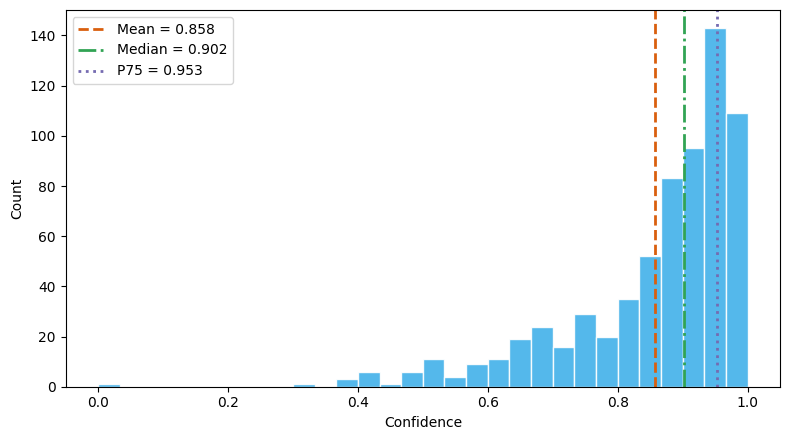

In [7]:
# Plot the distribution of confidence levels from the latest evaluation CSV
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Locate the latest evaluation CSV under ../inference_results/
root = Path.cwd().parent  # notebook is in data_exploration/, go up one level
results_dir = root / "inference_results"

candidates = sorted(results_dir.glob("evaluation_results_culturalheritagenus_Jawi-OCR-Qwen-v2.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
if not candidates:
    raise FileNotFoundError(f"No evaluation_results_culturalheritagenus_Jawi-OCR-Qwen-v2.csv found in {results_dir}")

csv_path = candidates[0]
print(f"Using results file: {csv_path}")

# Load
df = pd.read_csv(csv_path)
if "confidence" not in df.columns:
    raise KeyError(f"'confidence' column not found. Available columns: {list(df.columns)}")

conf = df["confidence"].dropna()

# Summary stats
summary = {
    "count": int(conf.shape[0]),
    "mean": float(conf.mean()),
    "std": float(conf.std(ddof=1)) if conf.shape[0] > 1 else 0.0,
    "min": float(conf.min()) if not conf.empty else None,
    "p10": float(conf.quantile(0.10)) if not conf.empty else None,
    "median": float(conf.median()) if not conf.empty else None,
    "p75": float(conf.quantile(0.75)) if not conf.empty else None,
    "p90": float(conf.quantile(0.90)) if not conf.empty else None,
    "max": float(conf.max()) if not conf.empty else None,
}
print("Summary:")
for k, v in summary.items():
    print(f"  {k:>6}: {v}")

# Plot histogram
plt.figure(figsize=(8, 4.5))
plt.hist(conf, bins=30, range=(0, 1), color="#41b1e9", edgecolor="white", alpha=0.9)
plt.xlabel("Confidence")
plt.ylabel("Count")

# Add vertical lines at the mean, median, and p75
if conf.shape[0] > 0:
    mean_val = conf.mean()
    median_val = conf.median()
    p75_val = conf.quantile(0.75)
    plt.axvline(mean_val, color="#d95f0e", linestyle="--", linewidth=2, label=f"Mean = {mean_val:.3f}")
    plt.axvline(median_val, color="#31a354", linestyle="-.", linewidth=2, label=f"Median = {median_val:.3f}")
    plt.axvline(p75_val, color="#756bb1", linestyle=":", linewidth=2, label=f"P75 = {p75_val:.3f}")
    plt.legend()

plt.tight_layout()
plt.show()

correct
False    516
True     162
Name: count, dtype: int64


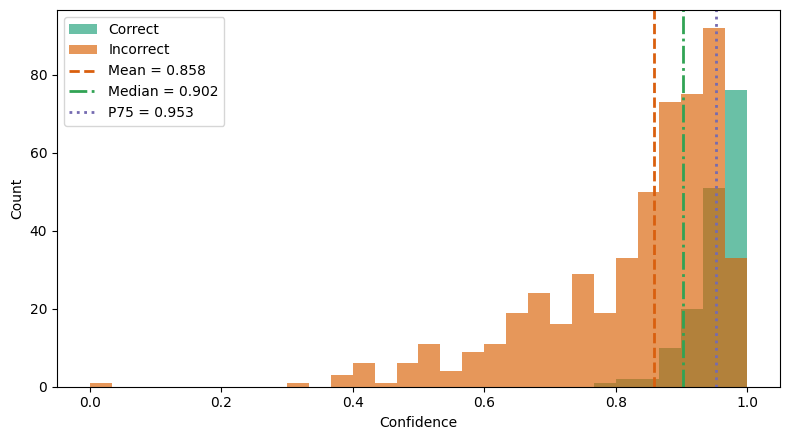

In [8]:
# Add correctness flag using normalization from performance_metrics.py and overlay histograms
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
sys.path.append(str(root))
from performance_metrics import normalize_text

# Reuse df and conf if available; else load again
if 'df' not in globals():
    results_dir = root / "inference_results"
    csv_path = sorted(results_dir.glob("evaluation_results_culturalheritagenus_Jawi-OCR-Qwen-v2.csv"), key=lambda p: p.stat().st_mtime, reverse=True)[0]
    df = pd.read_csv(csv_path)

# Compute correctness with normalization (exact string match after normalization)
df['gt_norm'] = df['ground_truth'].map(normalize_text)
df['pred_norm'] = df['prediction'].map(normalize_text)
df['correct'] = (df['gt_norm'] == df['pred_norm'])

print(df['correct'].value_counts())

# Overlayed histograms of confidence for correct vs incorrect
plt.figure(figsize=(8, 4.5))
plt.hist(df.loc[df['correct'], 'confidence'], bins=30, range=(0,1), color='#1b9e77', alpha=0.65, label='Correct')
plt.hist(df.loc[~df['correct'], 'confidence'], bins=30, range=(0,1), color='#d95f02', alpha=0.65, label='Incorrect')
plt.xlabel('Confidence')
plt.ylabel('Count')

# Add vertical lines for overall mean, median, and p75 (same as the first plot)
if 'confidence' in df.columns:
    conf_all = df['confidence'].dropna()
    if conf_all.shape[0] > 0:
        mean_val = conf_all.mean()
        median_val = conf_all.median()
        p75_val = conf_all.quantile(0.75)
        plt.axvline(mean_val, color='#d95f0e', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.3f}")
        plt.axvline(median_val, color='#31a354', linestyle='-.', linewidth=2, label=f"Median = {median_val:.3f}")
        plt.axvline(p75_val, color='#756bb1', linestyle=':', linewidth=2, label=f"P75 = {p75_val:.3f}")

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# What percentage of labels were replaced by GT across all labels_*.csv audit files?
from pathlib import Path
import pandas as pd

root = Path.cwd().parent
aug_dir = root / "augmented_data" / "Qwen2.5"

def compute_stats(csv_path: Path):
    df = pd.read_csv(csv_path)
    if 'chosen_source' not in df.columns:
        raise KeyError(f"{csv_path} has no 'chosen_source' column")
    total = len(df)
    gt_count = int((df['chosen_source'] == 'GT').sum())
    pred_count = total - gt_count
    pct_gt = (gt_count / total * 100.0) if total > 0 else 0.0
    return {
        'file': str(csv_path),
        'total_rows': total,
        'gt_replaced_count': gt_count,
        'pred_kept_count': pred_count,
        'percent_replaced_by_GT': round(pct_gt, 3),
        'percent_kept_as_pred': round(100.0 - pct_gt, 3)
    }

# Gather all labels_*.csv in augmented_data (or fallback to root if none)
candidates = []
if aug_dir.exists():
    candidates.extend(sorted(aug_dir.glob("v2_labels_*.csv")))
if not candidates:
    candidates.extend(sorted(root.glob("v2_labels_*.csv")))
if not candidates:
    raise FileNotFoundError("No labels_*.csv files found in augmented_data/ or project root.")

# Compute and print stats for each file
all_stats = [compute_stats(p) for p in candidates]
for s in all_stats:
    print(s)

{'file': '/Users/jon/Documents/FYP/Local Files/augmented_data/Qwen2.5/v2_labels_100_batch.csv', 'total_rows': 2034, 'gt_replaced_count': 1, 'pred_kept_count': 2033, 'percent_replaced_by_GT': 0.049, 'percent_kept_as_pred': 99.951}
{'file': '/Users/jon/Documents/FYP/Local Files/augmented_data/Qwen2.5/v2_labels_200_batch.csv', 'total_rows': 2034, 'gt_replaced_count': 2, 'pred_kept_count': 2032, 'percent_replaced_by_GT': 0.098, 'percent_kept_as_pred': 99.902}
{'file': '/Users/jon/Documents/FYP/Local Files/augmented_data/Qwen2.5/v2_labels_300_batch.csv', 'total_rows': 2034, 'gt_replaced_count': 8, 'pred_kept_count': 2026, 'percent_replaced_by_GT': 0.393, 'percent_kept_as_pred': 99.607}
{'file': '/Users/jon/Documents/FYP/Local Files/augmented_data/Qwen2.5/v2_labels_400_batch.csv', 'total_rows': 2034, 'gt_replaced_count': 27, 'pred_kept_count': 2007, 'percent_replaced_by_GT': 1.327, 'percent_kept_as_pred': 98.673}
{'file': '/Users/jon/Documents/FYP/Local Files/augmented_data/Qwen2.5/v2_labels

In [ ]:
thr_data_v1 = {
    "thresholds": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.903, 1.0],
    "GT": [0, 0.00105, 0.00633, 0.0195, 0.05904, 0.12862, 0.22298, 0.37217, 0.69584, 0.70532, 1],
    "Exact Match": [0.2302, 0.1989, 0.2044, 0.1989, 0.2136, 0.2192, 0.2210, 0.2578, 0.3499, 0.3517, 0.3959],
    "CER": [0.1237, 0.1343, 0.1425, 0.1332, 0.1248, 0.1088, 0.1017, 0.0898, 0.0704, 0.0734, 0.0653],
    "WER": [0.3743, 0.3967, 0.3955, 0.3921, 0.3858, 0.3530, 0.3385, 0.3143, 0.2600, 0.2683, 0.2444]
}

In [10]:
thr_data_v2 = {
    "thresholds": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.953, 1.0],
    "GT": [0.00049, 0.00098, 0.00393, 0.01327, 0.03245, 0.06834, 0.11259, 0.19174, 0.33235, 0.43756, 1],
    "Exact Match": [0.2537, 0.2448, 0.2463, 0.2419, 0.2478, 0.2522, 0.2434, 0.2670, 0.3038, 0.3245, 0.3791],
    "CER": [0.1070, 0.1068, 0.1081, 0.1097, 0.1019, 0.1061, 0.0991, 0.0912, 0.0865, 0.0847, 0.0831],
    "WER": [0.3470, 0.3467, 0.3499, 0.3524, 0.3473, 0.3455, 0.3392, 0.3193, 0.3009, 0.2901, 0.2701]
}

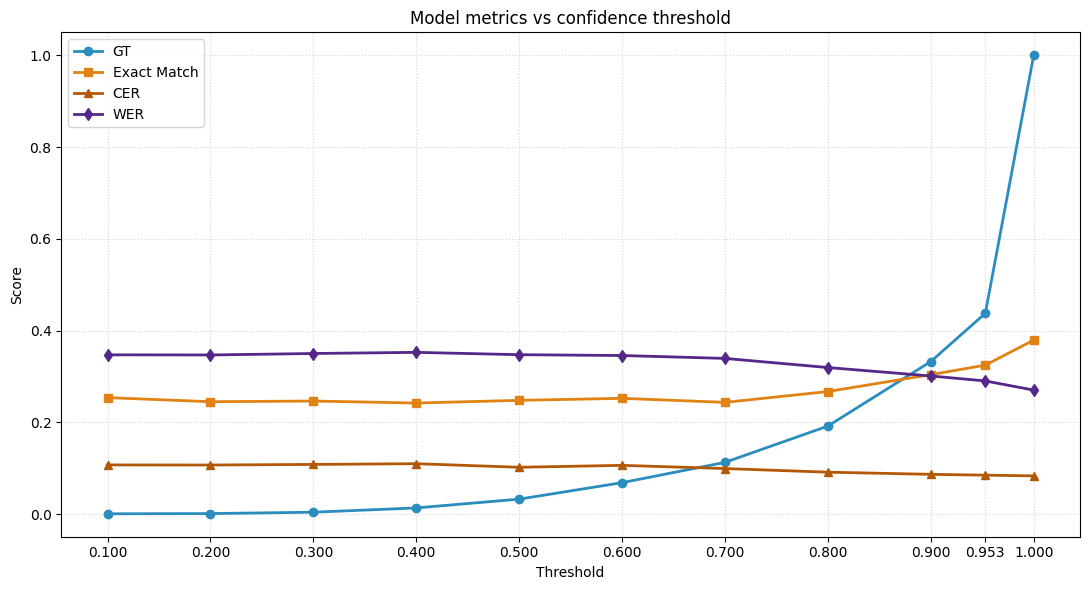

In [11]:
# Line graph of all metrics vs confidence threshold using thr_data
import matplotlib.pyplot as plt
import numpy as np

# Ensure thr_data exists
if 'thr_data_v2' not in globals():
    raise NameError("thr_data_v2 is not defined. Run the preceding cell that defines thr_data_v2 first.")

x = thr_data_v2.get('thresholds')
y_gt = thr_data_v2.get('GT')
y_em = thr_data_v2.get('Exact Match')
y_cer = thr_data_v2.get('CER')
y_wer = thr_data_v2.get('WER')
if x is None or y_gt is None:
    raise KeyError("thr_data must contain keys 'thresholds' and 'GT'")

plt.figure(figsize=(11, 6))
plt.plot(x, y_gt, color="#2b8cbe", marker="o", linewidth=2, label="GT")
plt.plot(x, y_em, color="#e08214", marker="s", linewidth=2, label="Exact Match")
plt.plot(x, y_cer, color="#b35806", marker="^", linewidth=2, label="CER")
plt.plot(x, y_wer, color="#542788", marker="d", linewidth=2, label="WER")

# Annotate the 0.903 point
try:
    idx_0903 = next(i for i, v in enumerate(x) if np.isclose(v, 0.903, atol=1e-9))
    x_val = x[idx_0903]
    
    # Annotate GT (blue)
    y_val_gt = y_gt[idx_0903]
    #plt.scatter([x_val], [y_val_gt], color="#ff6c3c", s=80, zorder=5)
    plt.annotate(f"({x_val:.3f}, {y_val_gt:.3f})", xy=(x_val, y_val_gt), xytext=(x_val-0.15, y_val_gt+0.08),
                 textcoords="data", arrowprops=dict(arrowstyle="->", color="#2b8cbe"),
                 fontsize=8, color='#2b8cbe', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#2b8cbe"))
    
    # Annotate Exact Match (orange)
    y_val_em = y_em[idx_0903]
    #plt.scatter([x_val], [y_val_em], color="#ff6c3c", s=80, zorder=5)
    plt.annotate(f"({x_val:.3f}, {y_val_em:.3f})", xy=(x_val, y_val_em), xytext=(x_val+0.02, y_val_em-0.05),
                 textcoords="data", arrowprops=dict(arrowstyle="->", color="#e08214"),
                 fontsize=8, color='#e08214', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#e08214"))
    
    # Annotate CER (brown)
    y_val_cer = y_cer[idx_0903]
    #plt.scatter([x_val], [y_val_cer], color="#ff6c3c", s=80, zorder=5)
    plt.annotate(f"({x_val:.3f}, {y_val_cer:.3f})", xy=(x_val, y_val_cer), xytext=(x_val+0.02, y_val_cer-0.04),
                 textcoords="data", arrowprops=dict(arrowstyle="->", color="#b35806"),
                 fontsize=8, color='#b35806', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#b35806"))
    
    # Annotate WER (purple)
    y_val_wer = y_wer[idx_0903]
    #plt.scatter([x_val], [y_val_wer], color="#ff6c3c", s=80, zorder=5)
    plt.annotate(f"({x_val:.3f}, {y_val_wer:.3f})", xy=(x_val, y_val_wer), xytext=(x_val-0.15, y_val_wer-0.05),
                 textcoords="data", arrowprops=dict(arrowstyle="->", color="#542788"),
                 fontsize=8, color='#542788', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#542788"))
except StopIteration:
    pass

plt.title("Model metrics vs confidence threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True, linestyle=":", alpha=0.5)
plt.xticks([t for t in x if not np.isclose(t, 0.903, atol=1e-9)])
plt.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

Dataset path: /Users/jon/Documents/FYP/OCR Data/data/train-00000-of-00001-82ad548e2f991d3f.parquet
Identifier: 0001_warmal_19380105_0001_20
Identifier: 0001_warmal_19380105_0001_20


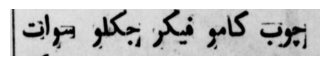

In [4]:
# Display the first image from the train parquet dataset (image only) and print the identifier
from pathlib import Path
import pandas as pd
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

root = Path.cwd().parent  # project root
parquet_path = root / "data" / "train-00000-of-00001-82ad548e2f991d3f.parquet"
print(f"Dataset path: {parquet_path}")

if not parquet_path.exists():
    raise FileNotFoundError(f"Parquet file not found at {parquet_path}.")

df = pd.read_parquet(parquet_path)
if df.empty:
    raise ValueError("Parquet file is empty.")

row0 = df.iloc[10]
identifier = row0.get('Identifier', '<no Identifier>')
print(f"Identifier: {identifier}")

# According to evaluate_model.py, each row's 'Image' is a dict with a 'bytes' key.
image_field = row0['Image']
if not isinstance(image_field, dict):
    raise TypeError(f"Expected 'Image' column to contain dict, got {type(image_field)}")
if 'bytes' not in image_field:
    raise KeyError("'bytes' key not found inside Image dict.")

image_bytes = image_field['bytes']
if not isinstance(image_bytes, (bytes, bytearray)):
    raise TypeError(f"Image['bytes'] is not raw bytes (type={type(image_bytes)})")

img = Image.open(BytesIO(image_bytes)).convert('RGB')

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# Inspect structure of the 'Image' column for the first row
import pprint, sys
row0 = df.iloc[0]
img_val = row0['Image']
print('Type of Image column value:', type(img_val))
print('Raw representation (truncated if too long):')
text_repr = repr(img_val)
if len(text_repr) > 500:
    print(text_repr[:500] + '...')
else:
    print(text_repr)

# If it's a dict-like, list keys
if isinstance(img_val, dict):
    print('\nDict keys:', list(img_val.keys()))
    for k,v in img_val.items():
        print(f"Key '{k}': type={type(v)}, length={len(v) if hasattr(v,'__len__') else 'NA'}")

# If it's bytes or memoryview report length
if isinstance(img_val, (bytes, bytearray, memoryview)):
    print('Byte length:', len(img_val))

# If it's a list/array, print length and first few elements
if hasattr(img_val, '__iter__') and not isinstance(img_val, (str, bytes, bytearray)):
    try:
        from itertools import islice
        preview = list(islice(iter(img_val), 10))
        print('Iterable preview (first 10 items):', preview)
    except Exception as e:
        print('Failed to preview iterable:', e)